In [4]:
from cirq_sic import *

d = 2
base_dir = "data/sky_ground"
wh_implementation = "simple"

psi_stab = np.eye(d)[0]
psi_sic = load_sic_fiducial(d)
interpolation = geodesic_interpolator(psi_stab, psi_sic)

T = np.linspace(0, 1, 15)
specs_t = {t: {"dataset_id": "interpolation",
               "processor_id": "willow_pink",
               "run_type": "noisy",
               "qubits": get_wh_qubits(d, wh_implementation),
               "n_shots": 50000,
               "optimizer": "cirq",
               "d": d,
               "fiducial": interpolation(t),
               "fiducial_description": f"interpolation_{np.round(t, 4)}",
               "wh_implementation": wh_implementation} for t in T}

for t, specs in specs_t.items():
    run_sky_ground_tasks(specs, base_dir=base_dir)

2025-10-24 13:50:58 [INFO] interpolation/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0/cirq_noisy_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2025-10-24 13:50:58 [INFO] interpolation/d2/WHPOVMOnBasisStatesTask/simple/interpolation_0.0/cirq_noisy_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2025-10-24 13:50:58 [INFO] interpolation/d2/BasisMeasurementOnWHStatesTask/interpolation_0.0/cirq_noisy_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2025-10-24 13:50:58 [INFO] interpolation/d2/BasisMeasurementOnBasisStatesTask/cirq_noisy_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2025-10-24 13:50:58 [INFO] interpolation/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0714/cirq_noisy_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2025-10-24 13:50:58 [INFO] interpolation/d2/WHPOVMOnBasisStatesTask/simple/interpolation_0.0714/cirq_noisy_n50k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2025-10-24 13:50:

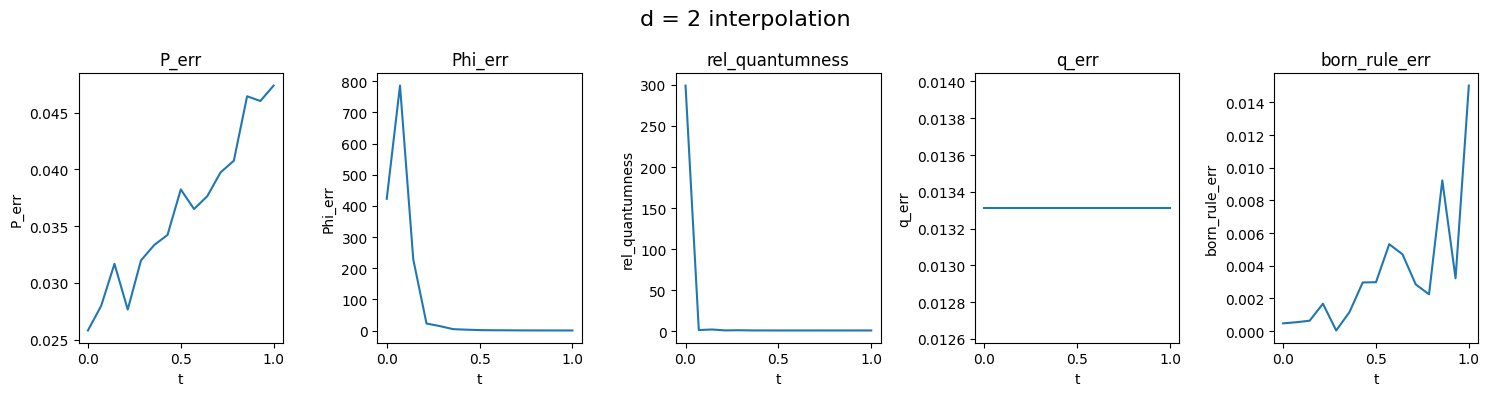

In [10]:
metrics_t = {t: sky_ground_metrics(specs_t[t]) for t in T}
metric_labels = metrics_t[0].keys()
fig, axes = plt.subplots(1, len(metric_labels), figsize=(15, 4))
for ax, metric_label in zip(axes, metric_labels):
    ax.plot(T, [metrics_t[t][metric_label] for t in T])
    ax.set_title(metric_label)
    ax.set_xlabel("t")
    ax.set_ylabel(metric_label)
    #ax.set_ylim(0, 10)
fig.suptitle(f"d = {d} interpolation", fontsize=16)
plt.tight_layout()
#fig.savefig(f"{filename}.pdf", bbox_inches='tight')
plt.show()

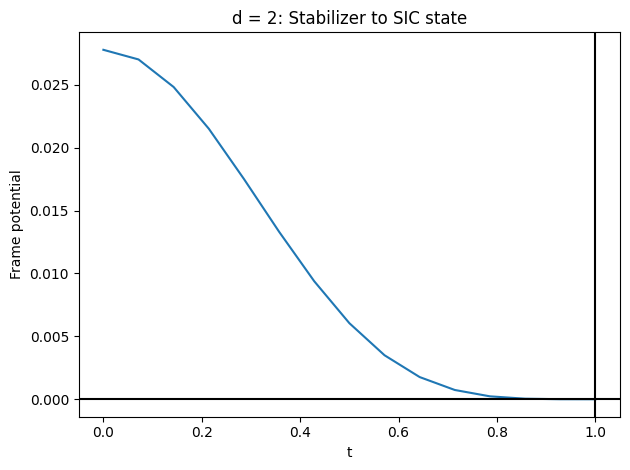

In [3]:
FP_img(d, interpolation, img_dir="img")

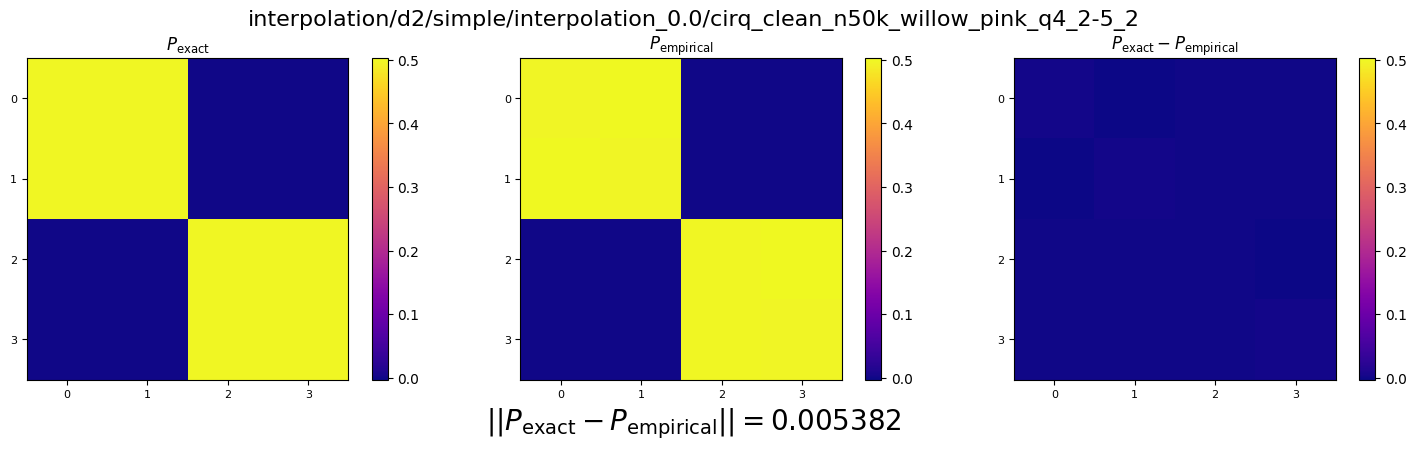

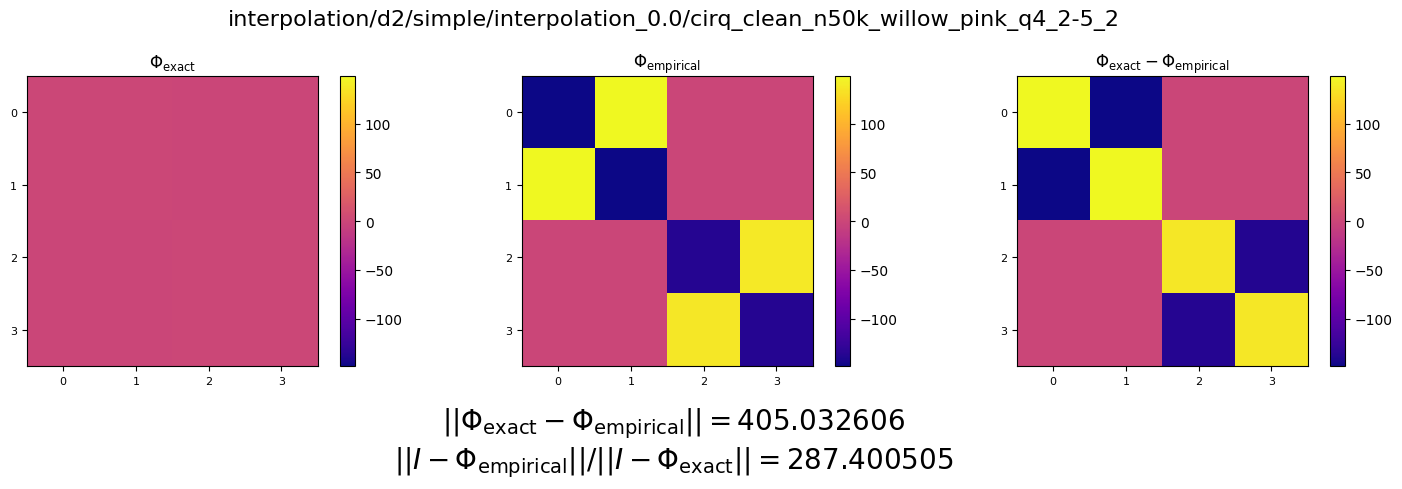

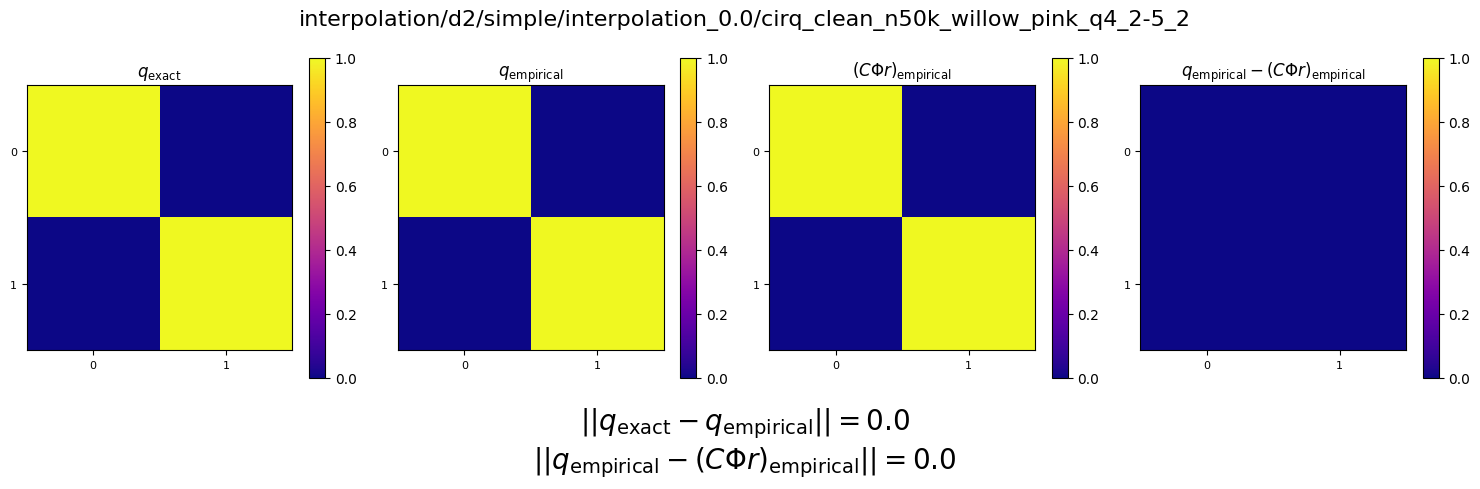

In [8]:
sky_ground_images(specs_t[0], img_path="img")

In [14]:
tasks, sg_results = load_sky_ground_results(specs_t[0], separate=True, base_dir=base_dir)

P = exactify(tasks[CharacterizeWHReferenceDeviceTask])["P"]
r = exactify(tasks[WHPOVMOnBasisStatesTask])["r"]
C = exactify(tasks[BasisMeasurementOnWHStatesTask])["C"]
q = exactify(tasks[BasisMeasurementOnBasisStatesTask])["q"]

In [15]:
C @ np.linalg.pinv(P) @ r

array([[1., 0.],
       [0., 1.]], dtype=float32)

In [16]:
C

array([[1., 1., 0., 0.],
       [0., 0., 1., 1.]], dtype=float32)

In [17]:
C @ np.linalg.pinv(P) @ r

array([[1., 0.],
       [0., 1.]], dtype=float32)